<a href="https://colab.research.google.com/github/Dania-Yasir/flyrak-project/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
%pip install -q duckdb huggingface_hub pandas numpy scikit-learn matplotlib

In [ ]:
import calendar
import json
import warnings
from pathlib import Path
from getpass import getpass

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
N_SPLITS = 5
DECLINE_THRESHOLD_PCT = -20.0

np.random.seed(RANDOM_STATE)

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


In [ ]:
try:
    from google.colab import userdata
    HF_TOKEN = userdata.get("HF_TOKEN")
except Exception:
    HF_TOKEN = None

if not HF_TOKEN:
    HF_TOKEN = getpass("Enter your Hugging Face READ token: ")

if not HF_TOKEN:
    raise ValueError("A Hugging Face READ token is required.")

con = duckdb.connect()

safe_token = HF_TOKEN.replace("'", "''")

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{safe_token}')"
)

REL = "hf://datasets/FlyRank/internship-warehouse"

print("Connected successfully.")

Connected successfully.


In [ ]:
# Feature groups are declared once and reused for March and the temporal holdout.

ANCHOR_FEATURES = [
    "imp_momentum_pct",
    "imp_momentum_log",
]

LEVEL_FEATURES = [
    "log_imp_first_half",
    "log_clicks_first_half",
    "ctr_first_half",
    "avg_position_first_half",
    "active_rate_first_half",
]

TREND_SHAPE_FEATURES = [
    "imp_step12_log",
    "imp_step23_log",
    "imp_acceleration",
    "imp_declining_steps",
    "imp_recent_vs_prior_log",
    "click_step23_log",
    "ctr_change_5d_pp",
    "position_change_5d",
    "active_rate_change_5d",
    "has_position_shape",
]

CLIENT_CONTEXT_FEATURES = [
    "log_imp_client_percentile",
    "ctr_client_percentile",
    "position_client_percentile",
    "recent_vs_prior_client_percentile",
]

CONTEXT_FEATURES = (
    LEVEL_FEATURES
    + TREND_SHAPE_FEATURES
    + CLIENT_CONTEXT_FEATURES
)
FULL_FEATURES = ANCHOR_FEATURES + CONTEXT_FEATURES

print("Momentum anchor features:", len(ANCHOR_FEATURES))
print("Context features:", len(CONTEXT_FEATURES))
print("Full features:", len(FULL_FEATURES))

Momentum anchor features: 2
Context features: 19
Full features: 21


In [ ]:
def safe_pct_change(new_value, old_value):
    denom = np.maximum(np.asarray(old_value, dtype=float), 1.0)
    return (
        (
            np.asarray(new_value, dtype=float)
            - np.asarray(old_value, dtype=float)
        )
        / denom
    ) * 100.0


def build_month_model_frame(month_str):
    """
    Build one month's feature population and outcome-evaluable cohort.

    Feature window: days 1-15.
    Outcome window: days 16-end of month.

    Client-relative ranks are computed on the pre-outcome feature population,
    before filtering on future coverage.
    """
    year, month = map(int, month_str.split("-"))
    last_day = calendar.monthrange(year, month)[1]
    future_days = last_day - 15

    d1 = f"{month_str}-01"
    d5 = f"{month_str}-05"
    d6 = f"{month_str}-06"
    d7 = f"{month_str}-07"
    d8 = f"{month_str}-08"
    d10 = f"{month_str}-10"
    d11 = f"{month_str}-11"
    d15 = f"{month_str}-15"
    d16 = f"{month_str}-16"
    dend = f"{month_str}-{last_day:02d}"

    fact = (
        f"read_parquet("
        f"'{REL}/fact_content_daily_performance/month={month_str}/*.parquet'"
        f")"
    )

    query = f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,

        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d5}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w1,
        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d5}'
                 THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w1,
        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d5}'
                 THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w1,
        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d5}'
                      AND COALESCE(gsc_impressions, 0) > 0
                 THEN 1 ELSE 0 END) AS active_days_w1,

        SUM(CASE WHEN report_date BETWEEN DATE '{d6}' AND DATE '{d10}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w2,
        SUM(CASE WHEN report_date BETWEEN DATE '{d6}' AND DATE '{d10}'
                 THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w2,
        SUM(CASE WHEN report_date BETWEEN DATE '{d6}' AND DATE '{d10}'
                 THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w2,
        SUM(CASE WHEN report_date BETWEEN DATE '{d6}' AND DATE '{d10}'
                      AND COALESCE(gsc_impressions, 0) > 0
                 THEN 1 ELSE 0 END) AS active_days_w2,

        SUM(CASE WHEN report_date BETWEEN DATE '{d11}' AND DATE '{d15}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_w3,
        SUM(CASE WHEN report_date BETWEEN DATE '{d11}' AND DATE '{d15}'
                 THEN COALESCE(gsc_clicks, 0) ELSE 0 END) AS clicks_w3,
        SUM(CASE WHEN report_date BETWEEN DATE '{d11}' AND DATE '{d15}'
                 THEN COALESCE(gsc_sum_position, 0) ELSE 0 END) AS sum_position_w3,
        SUM(CASE WHEN report_date BETWEEN DATE '{d11}' AND DATE '{d15}'
                      AND COALESCE(gsc_impressions, 0) > 0
                 THEN 1 ELSE 0 END) AS active_days_w3,

        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d7}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_early7,
        SUM(CASE WHEN report_date BETWEEN DATE '{d8}' AND DATE '{d15}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_late8,

        SUM(CASE WHEN report_date BETWEEN DATE '{d1}' AND DATE '{d15}'
                      AND COALESCE(gsc_data_available, FALSE)
                 THEN 1 ELSE 0 END) AS gsc_days_features,

        SUM(CASE WHEN report_date BETWEEN DATE '{d16}' AND DATE '{dend}'
                      AND COALESCE(gsc_data_available, FALSE)
                 THEN 1 ELSE 0 END) AS gsc_days_future,

        SUM(CASE WHEN report_date BETWEEN DATE '{d16}' AND DATE '{dend}'
                 THEN COALESCE(gsc_impressions, 0) ELSE 0 END) AS imp_future

    FROM {fact}
    WHERE report_date BETWEEN DATE '{d1}' AND DATE '{dend}'
    GROUP BY client_hash_id, content_hash_id
    """


    raw = (
    con.execute(query)
    .df()
    .sort_values(["client_id", "content_id"])
    .reset_index(drop=True)
)

    feature_pop = raw[
        raw["gsc_days_features"] == 15
    ].copy()

    feature_pop["imp_first_half"] = (
        feature_pop["imp_w1"]
        + feature_pop["imp_w2"]
        + feature_pop["imp_w3"]
    )
    feature_pop["clicks_first_half"] = (
        feature_pop["clicks_w1"]
        + feature_pop["clicks_w2"]
        + feature_pop["clicks_w3"]
    )
    feature_pop["sum_position_first_half"] = (
        feature_pop["sum_position_w1"]
        + feature_pop["sum_position_w2"]
        + feature_pop["sum_position_w3"]
    )
    feature_pop["active_days_first_half"] = (
        feature_pop["active_days_w1"]
        + feature_pop["active_days_w2"]
        + feature_pop["active_days_w3"]
    )

    feature_pop = feature_pop[
        feature_pop["imp_first_half"] > 0
    ].copy()

    feature_pop["avg_position_first_half"] = (
        feature_pop["sum_position_first_half"]
        / feature_pop["imp_first_half"]
    )
    feature_pop = feature_pop[
        feature_pop["avg_position_first_half"].notna()
        & (feature_pop["avg_position_first_half"] > 0)
    ].copy()

    # Stable level features.
    feature_pop["log_imp_first_half"] = np.log1p(
        feature_pop["imp_first_half"]
    )
    feature_pop["log_clicks_first_half"] = np.log1p(
        feature_pop["clicks_first_half"]
    )
    feature_pop["ctr_first_half"] = (
        feature_pop["clicks_first_half"]
        / feature_pop["imp_first_half"]
    ) * 100.0
    feature_pop["active_rate_first_half"] = (
        feature_pop["active_days_first_half"] / 15.0
    )

    # Momentum anchor.
    feature_pop["avg_daily_imp_early7"] = (
        feature_pop["imp_early7"] / 7.0
    )
    feature_pop["avg_daily_imp_late8"] = (
        feature_pop["imp_late8"] / 8.0
    )
    feature_pop["imp_momentum_pct"] = safe_pct_change(
        feature_pop["avg_daily_imp_late8"],
        feature_pop["avg_daily_imp_early7"],
    )
    feature_pop["imp_momentum_log"] = (
        np.log1p(feature_pop["avg_daily_imp_late8"])
        - np.log1p(feature_pop["avg_daily_imp_early7"])
    )

    # Three equal 5-day blocks.
    for w in (1, 2, 3):
        feature_pop[f"avg_daily_imp_w{w}"] = (
            feature_pop[f"imp_w{w}"] / 5.0
        )
        feature_pop[f"avg_daily_clicks_w{w}"] = (
            feature_pop[f"clicks_w{w}"] / 5.0
        )
        feature_pop[f"ctr_w{w}"] = np.where(
            feature_pop[f"imp_w{w}"] > 0,
            (
                feature_pop[f"clicks_w{w}"]
                / feature_pop[f"imp_w{w}"]
            ) * 100.0,
            0.0,
        )
        feature_pop[f"avg_position_w{w}"] = np.where(
            feature_pop[f"imp_w{w}"] > 0,
            (
                feature_pop[f"sum_position_w{w}"]
                / feature_pop[f"imp_w{w}"]
            ),
            np.nan,
        )
        feature_pop[f"active_rate_w{w}"] = (
            feature_pop[f"active_days_w{w}"] / 5.0
        )

    feature_pop["imp_step12_log"] = (
        np.log1p(feature_pop["avg_daily_imp_w2"])
        - np.log1p(feature_pop["avg_daily_imp_w1"])
    )
    feature_pop["imp_step23_log"] = (
        np.log1p(feature_pop["avg_daily_imp_w3"])
        - np.log1p(feature_pop["avg_daily_imp_w2"])
    )
    feature_pop["imp_acceleration"] = (
        feature_pop["imp_step23_log"]
        - feature_pop["imp_step12_log"]
    )
    feature_pop["imp_declining_steps"] = (
        (
            feature_pop["avg_daily_imp_w2"]
            < feature_pop["avg_daily_imp_w1"]
        ).astype(int)
        + (
            feature_pop["avg_daily_imp_w3"]
            < feature_pop["avg_daily_imp_w2"]
        ).astype(int)
    )
    feature_pop["imp_recent_vs_prior_log"] = (
        np.log1p(feature_pop["avg_daily_imp_w3"])
        - np.log1p(
            (
                feature_pop["avg_daily_imp_w1"]
                + feature_pop["avg_daily_imp_w2"]
            ) / 2.0
        )
    )
    feature_pop["click_step23_log"] = (
        np.log1p(feature_pop["avg_daily_clicks_w3"])
        - np.log1p(feature_pop["avg_daily_clicks_w2"])
    )
    feature_pop["ctr_change_5d_pp"] = (
        feature_pop["ctr_w3"]
        - feature_pop["ctr_w1"]
    )
    feature_pop["position_change_5d"] = (
        feature_pop["avg_position_w3"]
        - feature_pop["avg_position_w1"]
    ).fillna(0.0)
    feature_pop["has_position_shape"] = (
        feature_pop["avg_position_w1"].notna()
        & feature_pop["avg_position_w3"].notna()
    ).astype(int)
    feature_pop["active_rate_change_5d"] = (
        feature_pop["active_rate_w3"]
        - feature_pop["active_rate_w1"]
    )

    # Client-relative context uses PRE-OUTCOME data only.
    groups = feature_pop.groupby("client_id")
    feature_pop["log_imp_client_percentile"] = (
        groups["log_imp_first_half"].rank(pct=True)
    )
    feature_pop["ctr_client_percentile"] = (
        groups["ctr_first_half"].rank(pct=True)
    )
    feature_pop["position_client_percentile"] = (
        groups["avg_position_first_half"].rank(pct=True)
    )
    feature_pop["recent_vs_prior_client_percentile"] = (
        groups["imp_recent_vs_prior_log"].rank(pct=True)
    )

    model = feature_pop[
        feature_pop["gsc_days_future"] == future_days
    ].copy().reset_index(drop=True)

    model["avg_daily_imp_first_half"] = (
        model["imp_first_half"] / 15.0
    )
    model["avg_daily_imp_future"] = (
        model["imp_future"] / float(future_days)
    )
    model["impression_change_pct"] = (
        (
            model["avg_daily_imp_future"]
            - model["avg_daily_imp_first_half"]
        )
        / model["avg_daily_imp_first_half"]
    ) * 100.0
    model["is_declining_proxy"] = (
        model["impression_change_pct"]
        < DECLINE_THRESHOLD_PCT
    ).astype(int)

    info = {
        "month": month_str,
        "last_day": last_day,
        "future_days": future_days,
        "raw_rows": len(raw),
        "feature_rows": len(feature_pop),
        "model_rows": len(model),
        "clients": model["client_id"].nunique(),
    }

    return raw, feature_pop, model, info

In [ ]:
def make_balanced_client_splits(
    frame,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    n_restarts=500,
):
    """
    Client-disjoint K-fold splitter with an explicit client-count constraint.

    Guarantees:
    - each client appears in exactly one test fold;
    - fold client counts differ by at most one.

    Optimization target:
    - balance total rows;
    - balance positive rows;
    - balance decline base rate.

    Model performance is NEVER used when choosing the assignment.
    """
    stats = (
        frame.groupby("client_id")[target_col]
        .agg(rows="size", positives="sum")
        .reset_index()
    )
    stats["base_rate"] = (
        stats["positives"] / stats["rows"]
    )

    n_clients = len(stats)
    n_splits = min(int(n_splits), int(n_clients))

    if n_splits < 2:
        raise ValueError("At least two clients are required.")

    # Exact fold capacities.
    # Example: 34 clients, 5 folds -> [7, 7, 7, 7, 6].
    base = n_clients // n_splits
    remainder = n_clients % n_splits

    default_capacities = np.array(
        [
            base + (1 if i < remainder else 0)
            for i in range(n_splits)
        ],
        dtype=int,
    )

    total_rows = float(stats["rows"].sum())
    total_pos = float(stats["positives"].sum())
    global_rate = total_pos / total_rows

    target_rows = total_rows / n_splits
    target_pos = total_pos / n_splits

    rng_master = np.random.default_rng(random_state)
    best = None

    def final_cost(fold_rows, fold_pos):
        fold_rows = np.asarray(fold_rows, dtype=float)
        fold_pos = np.asarray(fold_pos, dtype=float)

        fold_rates = np.divide(
            fold_pos,
            fold_rows,
            out=np.zeros_like(fold_pos),
            where=fold_rows > 0,
        )

        row_imbalance = np.mean(
            ((fold_rows - target_rows) / max(target_rows, 1.0)) ** 2
        )
        pos_imbalance = np.mean(
            ((fold_pos - target_pos) / max(target_pos, 1.0)) ** 2
        )
        rate_imbalance = np.mean(
            (fold_rates - global_rate) ** 2
        )

        # Rows and positives matter most; rate balance is an additional guard.
        return (
            1.0 * row_imbalance
            + 1.25 * pos_imbalance
            + 3.0 * rate_imbalance
        )

    for restart in range(int(n_restarts)):
        rng = np.random.default_rng(
            int(rng_master.integers(0, 2**31 - 1))
        )

        # Randomly decide which folds receive the extra client(s),
        # so no fold number gets privileged.
        capacities = np.full(
            n_splits,
            base,
            dtype=int,
        )
        extra_order = rng.permutation(n_splits)
        capacities[extra_order[:remainder]] += 1

        work = stats.copy()

        # Place difficult-to-balance clients early:
        # large clients + clients with unusual base rate.
        work["_priority"] = (
            np.log1p(work["rows"])
            + 3.0 * np.abs(
                work["base_rate"] - global_rate
            )
            + rng.normal(
                0.0,
                0.05,
                size=len(work),
            )
        )
        work = (
            work.sort_values(
                "_priority",
                ascending=False,
            )
            .reset_index(drop=True)
        )

        fold_clients = [
            [] for _ in range(n_splits)
        ]
        fold_rows = np.zeros(
            n_splits,
            dtype=float,
        )
        fold_pos = np.zeros(
            n_splits,
            dtype=float,
        )

        for row in work.itertuples(index=False):
            eligible = [
                fold
                for fold in range(n_splits)
                if len(fold_clients[fold]) < capacities[fold]
            ]

            candidate_choices = []

            for fold in eligible:
                test_rows = fold_rows.copy()
                test_pos = fold_pos.copy()

                test_rows[fold] += float(row.rows)
                test_pos[fold] += float(row.positives)

                # Partial-state cost. Empty folds are intentionally penalized
                # through the row/positive imbalance terms.
                cost = final_cost(
                    test_rows,
                    test_pos,
                )

                candidate_choices.append(
                    (
                        cost,
                        rng.random(),
                        fold,
                    )
                )

            _, _, chosen_fold = min(
                candidate_choices
            )

            fold_clients[chosen_fold].append(
                row.client_id
            )
            fold_rows[chosen_fold] += float(
                row.rows
            )
            fold_pos[chosen_fold] += float(
                row.positives
            )

        score = final_cost(
            fold_rows,
            fold_pos,
        )

        if (
            best is None
            or score < best["score"]
        ):
            best = {
                "score": score,
                "fold_clients": [
                    list(x)
                    for x in fold_clients
                ],
                "fold_rows": fold_rows.copy(),
                "fold_pos": fold_pos.copy(),
            }

    splits = []

    for clients_in_fold in best["fold_clients"]:
        test_mask = frame["client_id"].isin(
            set(clients_in_fold)
        ).to_numpy()

        test_idx = np.flatnonzero(
            test_mask
        )
        train_idx = np.flatnonzero(
            ~test_mask
        )

        splits.append(
            (train_idx, test_idx)
        )

    # Verification.
    client_counts = [
        frame.iloc[test_idx]["client_id"].nunique()
        for _, test_idx in splits
    ]

    assert max(client_counts) - min(client_counts) <= 1

    all_test_clients = []
    for _, test_idx in splits:
        all_test_clients.extend(
            frame.iloc[test_idx][
                "client_id"
            ].drop_duplicates().tolist()
        )

    assert (
        len(all_test_clients)
        == len(set(all_test_clients))
        == frame["client_id"].nunique()
    )

    return splits, "BalancedClientKFold"

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

In [ ]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        C=0.3,
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=25,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Models ready.")

Models ready.


In [ ]:
raw_df, feature_population, model_df, march_info = (
    build_month_model_frame("2026-03")
)

target_col = "is_declining_proxy"

print("March data:")
print(march_info)
print("Decline rate:", f"{model_df[target_col].mean():.1%}")
print("Model rows:", f"{len(model_df):,}")
print("Clients:", model_df["client_id"].nunique())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March data:
{'month': '2026-03', 'last_day': 31, 'future_days': 16, 'raw_rows': 331437, 'feature_rows': 68288, 'model_rows': 61795, 'clients': 34}
Decline rate: 32.4%
Model rows: 61,795
Clients: 34


#OOF action queue

In [ ]:
grouped_splits, grouped_strategy = make_balanced_client_splits(
    model_df,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    n_restarts=500,
)

queue_frames = []

QUEUE_SIGNAL_COLS = [
    "client_id",
    "content_id",
    target_col,
    "imp_first_half",
    "clicks_first_half",
    "log_imp_first_half",
    "ctr_first_half",
    "avg_position_first_half",
    "active_rate_first_half",
    "imp_momentum_pct",
    "imp_momentum_log",
    "imp_step12_log",
    "imp_step23_log",
    "imp_acceleration",
    "imp_declining_steps",
    "imp_recent_vs_prior_log",
    "click_step23_log",
    "ctr_change_5d_pp",
    "position_change_5d",
    "active_rate_change_5d",
    "log_imp_client_percentile",
    "ctr_client_percentile",
    "position_client_percentile",
    "recent_vs_prior_client_percentile",
]

for fold, (train_idx, test_idx) in enumerate(grouped_splits, start=1):

    train_part = model_df.iloc[train_idx].copy()
    test_part = model_df.iloc[test_idx].copy()

    rf = clone(random_forest_model)

    rf.fit(
        train_part[FULL_FEATURES],
        train_part[target_col],
    )

    rf_scores = rf.predict_proba(
        test_part[FULL_FEATURES]
    )[:, 1]

    fold_queue = test_part[QUEUE_SIGNAL_COLS].copy()

    fold_queue["fold"] = fold
    fold_queue["model_risk_score"] = rf_scores

    # Make scores comparable across folds without assuming
    # identical probability calibration.
    fold_queue["risk_percentile"] = (
        pd.Series(rf_scores, index=fold_queue.index)
        .rank(method="average", pct=True)
    )

    queue_frames.append(fold_queue)

action_queue = pd.concat(queue_frames, ignore_index=True)

assert len(action_queue) == len(model_df)
assert action_queue["content_id"].duplicated().sum() == 0

print("OOF rows:", f"{len(action_queue):,}")
print("Duplicate content IDs:",
      action_queue["content_id"].duplicated().sum())

display(
    action_queue[
        [
            "fold",
            "model_risk_score",
            "risk_percentile",
            "imp_momentum_pct",
            "imp_declining_steps",
            "avg_position_first_half",
            target_col,
        ]
    ]
    .sort_values("risk_percentile", ascending=False)
    .head(10)
)

OOF rows: 61,795
Duplicate content IDs: 0


,fold,model_risk_score,risk_percentile,imp_momentum_pct,imp_declining_steps,avg_position_first_half,is_declining_proxy
45732,4,0.914527,1.000000,-74.189331,2,7.867528,1
59975,5,0.928342,1.000000,-91.320375,2,6.439024,1
7364,1,0.939493,1.000000,-62.814703,1,9.990813,1
27156,3,0.916512,1.000000,-37.044374,1,41.282028,1
11320,2,0.914005,1.000000,-84.264305,2,9.069284,1
37512,4,0.912079,0.999940,-56.934878,2,7.480487,1
49520,5,0.926091,0.999922,-83.202859,2,8.129069,1
11304,2,0.906425,0.999909,-75.921763,1,8.971791,1
7479,1,0.938608,0.999907,-66.123188,2,13.919403,1
26223,3,0.910336,0.999905,-39.339539,2,58.904712,0


#Reason codes

In [ ]:
def build_reason_codes(row):
    reasons = []

    # Absolute recent deterioration
    if row["imp_momentum_pct"] <= -20:
        reasons.append("RECENT_IMPRESSION_DROP")

    # More persistent shape, not only one noisy step
    if row["imp_declining_steps"] >= 2:
        reasons.append("SUSTAINED_DECLINE_SHAPE")

    # Unusually weak movement relative to pages of the same client
    if row["recent_vs_prior_client_percentile"] <= 0.20:
        reasons.append("CLIENT_RELATIVE_DROPOFF")

    # Search position number increased = ranking position worsened
    if row["position_change_5d"] >= 2:
        reasons.append("POSITION_WORSENING")

    # CTR is weak relative to other pages from the same client
    if row["ctr_client_percentile"] <= 0.25:
        reasons.append("LOW_RELATIVE_CTR")

    # Existing search visibility
    if (
        row["avg_position_first_half"] > 0
        and row["avg_position_first_half"] <= 20
    ):
        reasons.append("TOP20_VISIBILITY")

    # Larger visible opportunity inside the client
    if row["log_imp_client_percentile"] >= 0.75:
        reasons.append("HIGH_RELATIVE_EXPOSURE")

    if not reasons:
        reasons.append("MODEL_PATTERN_ONLY")

    return "|".join(reasons)


action_queue["reason_codes"] = action_queue.apply(
    build_reason_codes,
    axis=1,
)

action_queue[
    ["risk_percentile", "reason_codes"]
].head()

,risk_percentile,reason_codes
0,0.299833,SUSTAINED_DECLINE_SHAPE|TOP20_VISIBILITY
1,0.726818,LOW_RELATIVE_CTR|TOP20_VISIBILITY|HIGH_RELATIV...
2,0.536461,SUSTAINED_DECLINE_SHAPE|LOW_RELATIVE_CTR|TOP20...
3,0.511475,POSITION_WORSENING|LOW_RELATIVE_CTR
4,0.728854,POSITION_WORSENING|LOW_RELATIVE_CTR


#Archetype → Action mapping

In [ ]:
def assign_archetype(row):

    reasons = set(row["reason_codes"].split("|"))
    risk = row["risk_percentile"]

    # Model risk is the first gate.
    # Only the top 20% enters the active review queue.
    if risk < 0.50:
        return "MONITOR"

    if risk < 0.80:
        return "WATCHLIST"

    # High-risk pages: reason codes determine review type.
    if {
        "RECENT_IMPRESSION_DROP",
        "SUSTAINED_DECLINE_SHAPE",
    }.issubset(reasons):
        return "SUSTAINED_DECAY"

    if (
        "POSITION_WORSENING" in reasons
        and "RECENT_IMPRESSION_DROP" in reasons
    ):
        return "RANKING_SLIPPAGE"

    if (
        "TOP20_VISIBILITY" in reasons
        and "LOW_RELATIVE_CTR" in reasons
    ):
        return "VISIBLE_LOW_CTR"

    if "CLIENT_RELATIVE_DROPOFF" in reasons:
        return "CLIENT_RELATIVE_ANOMALY"

    # High model risk without a clean heuristic explanation.
    return "HIGH_RISK_AMBIGUOUS"

In [ ]:
ACTION_MAP = {
    "SUSTAINED_DECAY":
        "CONTENT_REFRESH_REVIEW",

    "RANKING_SLIPPAGE":
        "SERP_AND_INTENT_REVIEW",

    "VISIBLE_LOW_CTR":
        "TITLE_META_CTR_REVIEW",

    "CLIENT_RELATIVE_ANOMALY":
        "MANUAL_DIAGNOSTIC_REVIEW",

    "HIGH_RISK_AMBIGUOUS":
        "HUMAN_REVIEW_BEFORE_EDIT",

    "WATCHLIST":
        "WATCHLIST_NO_IMMEDIATE_EDIT",

    "MONITOR":
        "MONITOR_NO_IMMEDIATE_EDIT",
}


action_queue["archetype"] = action_queue.apply(
    assign_archetype,
    axis=1,
)

action_queue["recommended_action"] = (
    action_queue["archetype"].map(ACTION_MAP)
)
EFFORT_MAP = {
    "CONTENT_REFRESH_REVIEW": "HIGH",
    "SERP_AND_INTENT_REVIEW": "MEDIUM",
    "TITLE_META_CTR_REVIEW": "LOW",
    "MANUAL_DIAGNOSTIC_REVIEW": "MEDIUM",
    "HUMAN_REVIEW_BEFORE_EDIT": "MEDIUM",
    "WATCHLIST_NO_IMMEDIATE_EDIT": "LOW",
    "MONITOR_NO_IMMEDIATE_EDIT": "LOW",
}

#Cost/value thinking

In [ ]:
def value_tier(row):
    p = row["log_imp_client_percentile"]

    if p >= 0.75:
        return "HIGH"
    elif p >= 0.25:
        return "MEDIUM"
    return "LOW"


EFFORT_MAP = {
    "CONTENT_REFRESH_REVIEW": "HIGH",
    "SERP_AND_INTENT_REVIEW": "MEDIUM",
    "TITLE_META_CTR_REVIEW": "LOW",
    "MANUAL_DIAGNOSTIC_REVIEW": "MEDIUM",
    "HUMAN_REVIEW_BEFORE_EDIT": "MEDIUM",
    "MONITOR_NO_IMMEDIATE_EDIT": "LOW",
}


action_queue["value_tier"] = action_queue.apply(
    value_tier,
    axis=1,
)

action_queue["effort_tier"] = (
    action_queue["recommended_action"].map(EFFORT_MAP)
)

In [ ]:
display(
    action_queue[
        [
            "risk_percentile",
            "log_imp_client_percentile",
            "value_tier",
            "recommended_action",
            "effort_tier",
        ]
    ].head(10)
)

,risk_percentile,log_imp_client_percentile,value_tier,recommended_action,effort_tier
0,0.299833,0.371631,MEDIUM,MONITOR_NO_IMMEDIATE_EDIT,LOW
1,0.726818,0.894830,HIGH,WATCHLIST_NO_IMMEDIATE_EDIT,NaN
2,0.536461,0.268228,MEDIUM,WATCHLIST_NO_IMMEDIATE_EDIT,NaN
3,0.511475,0.417808,MEDIUM,WATCHLIST_NO_IMMEDIATE_EDIT,NaN
4,0.728854,0.452718,MEDIUM,WATCHLIST_NO_IMMEDIATE_EDIT,NaN
5,0.632519,0.691560,MEDIUM,WATCHLIST_NO_IMMEDIATE_EDIT,NaN
6,0.108458,0.106385,LOW,MONITOR_NO_IMMEDIATE_EDIT,LOW
7,0.009994,0.010163,LOW,MONITOR_NO_IMMEDIATE_EDIT,LOW
8,0.868592,0.794300,HIGH,MANUAL_DIAGNOSTIC_REVIEW,MEDIUM
9,0.185175,0.529607,MEDIUM,MONITOR_NO_IMMEDIATE_EDIT,LOW


In [ ]:
VALUE_ORDER = {
    "HIGH": 3,
    "MEDIUM": 2,
    "LOW": 1,
}

action_queue["value_order"] = (
    action_queue["value_tier"].map(VALUE_ORDER)
)

action_queue = (
    action_queue
    .sort_values(
        ["risk_percentile", "value_order", "imp_first_half"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

action_queue["queue_rank"] = np.arange(len(action_queue)) + 1

action_queue["priority_score"] = (
    action_queue["risk_percentile"] * 100
).round(3)

display(
    action_queue[
        [
            "queue_rank",
            "priority_score",
            "value_tier",
            "effort_tier",
            "archetype",
            "recommended_action",
            "reason_codes",
        ]
    ].head(20)
)

,queue_rank,priority_score,value_tier,effort_tier,archetype,recommended_action,reason_codes
0,1,100.000,HIGH,MEDIUM,RANKING_SLIPPAGE,SERP_AND_INTENT_REVIEW,RECENT_IMPRESSION_DROP|CLIENT_RELATIVE_DROPOFF...
1,2,100.000,MEDIUM,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...
2,3,100.000,MEDIUM,MEDIUM,RANKING_SLIPPAGE,SERP_AND_INTENT_REVIEW,RECENT_IMPRESSION_DROP|CLIENT_RELATIVE_DROPOFF...
3,4,100.000,MEDIUM,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...
4,5,100.000,MEDIUM,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...
5,6,99.994,HIGH,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...
6,7,99.992,HIGH,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...
7,8,99.991,MEDIUM,MEDIUM,RANKING_SLIPPAGE,SERP_AND_INTENT_REVIEW,RECENT_IMPRESSION_DROP|CLIENT_RELATIVE_DROPOFF...
8,9,99.991,MEDIUM,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...
9,10,99.990,MEDIUM,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...


In [ ]:
print("Recommended action distribution:")

display(
    action_queue["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="pages")
)

print("\nArchetype distribution:")

display(
    action_queue["archetype"]
    .value_counts()
    .rename_axis("archetype")
    .reset_index(name="pages")
)

Recommended action distribution:


,recommended_action,pages
0,MONITOR_NO_IMMEDIATE_EDIT,30893
1,WATCHLIST_NO_IMMEDIATE_EDIT,18540
2,CONTENT_REFRESH_REVIEW,6493
3,MANUAL_DIAGNOSTIC_REVIEW,2313
4,HUMAN_REVIEW_BEFORE_EDIT,1899
5,TITLE_META_CTR_REVIEW,942
6,SERP_AND_INTENT_REVIEW,715



Archetype distribution:


,archetype,pages
0,MONITOR,30893
1,WATCHLIST,18540
2,SUSTAINED_DECAY,6493
3,CLIENT_RELATIVE_ANOMALY,2313
4,HIGH_RISK_AMBIGUOUS,1899
5,VISIBLE_LOW_CTR,942
6,RANKING_SLIPPAGE,715


In [ ]:
reason_counts = (
    action_queue["reason_codes"]
    .str.split("|")
    .explode()
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="pages")
)

print("Reason code distribution:")

display(reason_counts)

Reason code distribution:


,reason_code,pages
0,TOP20_VISIBILITY,49035
1,LOW_RELATIVE_CTR,21615
2,RECENT_IMPRESSION_DROP,21196
3,SUSTAINED_DECLINE_SHAPE,18563
4,HIGH_RELATIVE_EXPOSURE,17157
5,POSITION_WORSENING,17125
6,CLIENT_RELATIVE_DROPOFF,12027
7,MODEL_PATTERN_ONLY,1183


In [ ]:
action_risk_audit = (
    action_queue
    .groupby(
        ["archetype", "recommended_action"],
        observed=True
    )["risk_percentile"]
    .agg(
        pages="size",
        median_risk="median",
        min_risk="min",
        max_risk="max",
    )
    .reset_index()
    .sort_values("median_risk", ascending=False)
)

display(
    action_risk_audit.style.format({
        "median_risk": "{:.1%}",
        "min_risk": "{:.1%}",
        "max_risk": "{:.1%}",
    })
)

high_risk_monitor = action_queue[
    (action_queue["risk_percentile"] >= 0.80)
    & (action_queue["archetype"] == "MONITOR")
]

print(
    "High-risk pages mapped to MONITOR:",
    len(high_risk_monitor)
)

,archetype,recommended_action,pages,median_risk,min_risk,max_risk
3,RANKING_SLIPPAGE,SERP_AND_INTENT_REVIEW,715,92.0%,80.0%,100.0%
4,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,6493,91.5%,80.0%,100.0%
5,VISIBLE_LOW_CTR,TITLE_META_CTR_REVIEW,942,88.7%,80.0%,99.8%
0,CLIENT_RELATIVE_ANOMALY,MANUAL_DIAGNOSTIC_REVIEW,2313,86.9%,80.0%,100.0%
1,HIGH_RISK_AMBIGUOUS,HUMAN_REVIEW_BEFORE_EDIT,1899,86.3%,80.0%,99.8%
6,WATCHLIST,WATCHLIST_NO_IMMEDIATE_EDIT,18540,65.0%,50.0%,80.0%
2,MONITOR,MONITOR_NO_IMMEDIATE_EDIT,30893,25.0%,0.0%,50.0%


High-risk pages mapped to MONITOR: 0


### How to read this queue

This playbook starts from out-of-fold scores produced by the same Random Forest — Full Signal model used in the final validation.

The model score determines review priority. The reason codes describe observable pre-outcome signals that help a human understand why a page may deserve attention. They are heuristic explanations, not causal explanations and not proof that a specific content edit will improve performance.

The archetype rules are applied in order, so each page receives one primary action even when several reason codes are present. The resulting action is a review recommendation, not an automatic publishing decision.

Relative exposure is used only as a value proxy and tie-breaker. It is not a financial value estimate or validated ROI measure.

### Decay / refresh insight

The observed data supports using recent deterioration as a signal for prioritizing review. Persistent impression decline, worsening search position, and unusually weak movement relative to the client's other pages can identify cases worth examining first.

However, decline risk should not be translated directly into an automatic refresh. Earlier analysis also showed that short-term deterioration can recover and that some future declines begin without a strong warning signal.

For this playbook, a refresh recommendation therefore means **review the page for possible refresh**, not **rewrite the page automatically**. A human should first check search intent, SERP changes, CTR, business importance, content accuracy, and whether the page is actually stale.

The 80th-percentile threshold is an operational review-capacity rule, not a learned or causally validated cutoff. It limits active recommendations to the highest-risk portion of the queue, while lower-risk pages remain on the watchlist or monitoring tier.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
use_and_limits = pd.DataFrame([
    {
    "item": "Validity boundary",
    "definition": "Revalidate before use if the data definition, feature window, client/content population, or observed model performance changes materially."
},
    {
        "item": "Intended user",
        "definition": "Content / SEO analyst reviewing pages for possible intervention."
    },
    {
        "item": "Decision supported",
        "definition": "Which pages should be reviewed first, and what type of review may be appropriate."
    },
    {
        "item": "Unit of analysis",
        "definition": "One pseudonymized content page within a client."
    },
    {
        "item": "Active review threshold",
        "definition": "Top 20% of within-fold model risk (risk percentile >= 0.80)."
    },
    {
        "item": "Watchlist",
        "definition": "Risk percentile from 0.50 to below 0.80."
    },
    {
        "item": "Monitor",
        "definition": "Risk percentile below 0.50."
    },
    {
        "item": "Value proxy",
        "definition": "Relative first-half impression exposure within the same client; not revenue or ROI."
    },
    {
        "item": "Output",
        "definition": "A ranked human-review queue with reason codes and suggested review actions."
    },
])


display(use_and_limits)

,item,definition
0,Validity boundary,"Revalidate before use if the data definition, ..."
1,Intended user,Content / SEO analyst reviewing pages for poss...
2,Decision supported,"Which pages should be reviewed first, and what..."
3,Unit of analysis,One pseudonymized content page within a client.
4,Active review threshold,Top 20% of within-fold model risk (risk percen...
5,Watchlist,Risk percentile from 0.50 to below 0.80.
6,Monitor,Risk percentile below 0.50.
7,Value proxy,Relative first-half impression exposure within...
8,Output,A ranked human-review queue with reason codes ...


### Intended use

This playbook is designed as a **decision-support tool for content and SEO analysts**.

Its purpose is to prioritize pages for human review. The model identifies pages with higher observed risk of the future-decline proxy, while the playbook adds descriptive reason codes and a suggested type of review.

The operating policy used here is:

- **Risk percentile >= 0.80:** active human review
- **0.50 <= risk percentile < 0.80:** watchlist
- **Risk percentile < 0.50:** monitor

These thresholds are practical review-capacity rules. They were not learned by the model and should not be interpreted as statistically optimal cutoffs.

The `value_tier` is based on relative impression exposure within each client. It helps prioritize pages that currently receive more search visibility, but it is **not a measure of revenue, profit, business value, or expected ROI**.

### Limits

The model predicts a specific proxy: whether average daily impressions in the outcome window decline by more than 20% relative to the feature window. It does not directly predict ranking loss, traffic loss, revenue loss, or a Google algorithm change.

The primary evidence comes from client-disjoint validation on one main time period. Keeping clients separated makes the test more realistic than a random row split, but it does not prove that performance will remain the same for every future month, client, or content type.

Model risk scores are used for ranking and prioritization. They should not be interpreted as calibrated probabilities of decline.

Reason codes describe observable pre-outcome conditions. They are heuristic context for reviewers, not causal explanations of the model and not proof that any individual feature caused a decline.

The recommended actions have not been experimentally validated as treatments. For example, `CONTENT_REFRESH_REVIEW` means that a page should be inspected for possible refresh; it does not mean that refreshing the page will recover impressions.

The queue therefore supports **human prioritization, not autonomous content decisions**.

### When this playbook stops being valid

This playbook should not be treated as current evidence indefinitely.

It should be revalidated before continued use when:

- the warehouse schema, feature definitions, or decline-proxy definition changes;
- the prediction window or outcome window changes from the design used in training;
- the system is applied to substantially different clients or content types;
- important input features become unavailable or their distributions change materially;
- monitored ranking performance degrades relative to the validated benchmark.

A change in any of these conditions does not automatically mean the model has failed. It means the existing validation evidence may no longer support the same claims.

The specific monitoring and retraining triggers are defined in Section 4.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
human_review_policy = pd.DataFrame([
    {
        "stage": "1. Prioritize",
        "rule": "Use model risk to decide which pages should be reviewed first."
    },
    {
        "stage": "2. Inspect",
        "rule": "Review trend, ranking, CTR, intent, freshness, seasonality, and business context."
    },
    {
        "stage": "3. Decide",
        "rule": "A human reviewer decides whether any content or SEO change is justified."
    },
    {
        "stage": "4. Execute",
        "rule": "Changes are made only after human approval through the normal content workflow."
    },
])

display(human_review_policy)

,stage,rule
0,1. Prioritize,Use model risk to decide which pages should be...
1,2. Inspect,"Review trend, ranking, CTR, intent, freshness,..."
2,3. Decide,A human reviewer decides whether any content o...
3,4. Execute,Changes are made only after human approval thr...


In [ ]:
no_go_policy = pd.DataFrame([
    {"do_not_automate": "Rewrite or publish page content"},
    {"do_not_automate": "Change titles or meta descriptions"},
    {"do_not_automate": "Delete, redirect, deindex, or change canonical URLs"},
    {"do_not_automate": "Treat a refresh recommendation as proof that refresh will improve performance"},
    {"do_not_automate": "Make business decisions from model score alone"},
    {"do_not_automate": "Automatically retrain or deploy the model"},
])

display(no_go_policy)

,do_not_automate
0,Rewrite or publish page content
1,Change titles or meta descriptions
2,"Delete, redirect, deindex, or change canonical..."
3,Treat a refresh recommendation as proof that r...
4,Make business decisions from model score alone
5,Automatically retrain or deploy the model


### Human-review rule

The playbook follows a human-in-the-loop workflow:

**Model prioritizes → human investigates → human decides.**

A high model-risk score is a reason to inspect a page earlier. It is not an instruction to edit the page.

Before any intervention, the reviewer should check:

- whether the decline appears persistent or may be temporary volatility;
- ranking and SERP changes;
- CTR behavior;
- whether search intent appears to have changed;
- whether the content is actually outdated or incomplete;
- seasonality, campaigns, or external events that may explain the movement;
- the page's business importance and any operational constraints.

If the model identifies high risk but the reason codes do not provide a clear explanation, the page should remain under `HUMAN_REVIEW_BEFORE_EDIT`. Uncertainty should lead to more investigation, not stronger automation.

### No-go list

The following actions must not be automated from the model score or playbook recommendation alone:

- rewriting or publishing page content;
- changing titles or meta descriptions;
- deleting, redirecting, deindexing, or changing canonical URLs;
- changing URLs or page structure;
- treating `CONTENT_REFRESH_REVIEW` as an instruction to refresh;
- claiming that a reason code caused the observed decline;
- making business or financial decisions from the model score alone;
- automatically retraining, deploying, or replacing the model without review.

The playbook also should not expose private client names, raw search queries, or other sensitive client information in public outputs.

The purpose of the system is to reduce the amount of content a reviewer must inspect first. Final decisions remain with the human reviewer.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
VALIDATED_P100 = 0.746
PERFORMANCE_WARNING_P100 = VALIDATED_P100 - 0.10

monitoring_policy = pd.DataFrame([
    {
        "monitor": "Ranking performance",
        "warning_signal": (
            "Precision@100 falls more than 10 percentage points "
            "below the validated 74.6% benchmark."
        ),
        "response": (
            "Investigate one weak evaluation window; consider retraining "
            "if degradation persists across two fully observed windows."
        ),
    },
    {
        "monitor": "Target prevalence",
        "warning_signal": (
            "The future-decline rate changes materially from "
            "the validation population."
        ),
        "response": (
            "Check whether the content population, seasonality, "
            "or target-generating process has changed; revalidate."
        ),
    },
    {
        "monitor": "Feature quality",
        "warning_signal": (
            "Important features become missing, unavailable, "
            "or show large distribution shifts."
        ),
        "response": (
            "Check the data pipeline and feature definitions "
            "before using the recommendations."
        ),
    },
    {
        "monitor": "Client / content population",
        "warning_signal": (
            "The model is used on substantially different clients, "
            "content types, or traffic patterns."
        ),
        "response": (
            "Evaluate the existing model on the new population before "
            "assuming the original validation still applies."
        ),
    },
    {
        "monitor": "Data contract",
        "warning_signal": (
            "The warehouse schema, feature window, outcome window, "
            "or decline-proxy definition changes."
        ),
        "response": (
            "Treat the existing validation as no longer directly "
            "applicable and run a fresh validation."
        ),
    },
])

display(monitoring_policy)

print(
    "Operational performance warning level:",
    f"{PERFORMANCE_WARNING_P100:.1%}",
)

,monitor,warning_signal,response
0,Ranking performance,Precision@100 falls more than 10 percentage po...,Investigate one weak evaluation window; consid...
1,Target prevalence,The future-decline rate changes materially fro...,"Check whether the content population, seasonal..."
2,Feature quality,"Important features become missing, unavailable...",Check the data pipeline and feature definition...
3,Client / content population,The model is used on substantially different c...,Evaluate the existing model on the new populat...
4,Data contract,"The warehouse schema, feature window, outcome ...",Treat the existing validation as no longer dir...


Operational performance warning level: 64.6%


### What would tell me the recommendations went stale?

The recommendations should be treated as potentially stale when the conditions behind the original validation no longer match the current operating environment.

The clearest signal is **performance degradation**. Under the deterministic client-disjoint validation, the Random Forest — Full Signal model achieved approximately **74.6% Precision@100 (SD 13.6%)**.

For lightweight monitoring, I use an operational warning if Precision@100 falls more than **10 percentage points** below that benchmark. This gives a warning level of **64.6% Precision@100**.

The threshold is a practical monitoring rule, not a statistically optimized cutoff.

A single weak evaluation window should trigger investigation, not automatic retraining. Short-term variation may reflect seasonality, unusual clients, or a changed content mix.

If degradation persists across multiple fully observed evaluation windows, the model should be revalidated and retraining considered.

Other warning signals are:

- important input features become unavailable or shift materially;
- the future-decline prevalence changes substantially;
- the model is applied to new client or content populations not represented in the validation evidence;
- the warehouse schema, feature window, outcome window, or decline-proxy definition changes.

### Revalidate before retraining

A monitoring trigger is **not** an automatic retraining instruction.

The intended sequence is:

**Monitor → investigate → revalidate → retrain only if needed.**

Retraining becomes reasonable when there is evidence that the feature–outcome relationship has changed, the operating population has shifted materially, or the data/target definition has changed.

Automatic retraining or deployment is outside this playbook.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
from pathlib import Path
import json
import shutil

# Required project locations
OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("Queue / metrics directory:", OUTPUT_DIR.resolve())
print("Figures directory:", FIGURE_DIR.resolve())

Current working directory: /content
Queue / metrics directory: /content/work/outputs
Figures directory: /content/work/figures


In [ ]:
EXPORT_COLUMNS = [
    "queue_rank",
    "content_id",
    "client_id",
    "priority_score",
    "risk_percentile",
    "model_risk_score",
    "value_tier",
    "effort_tier",
    "archetype",
    "recommended_action",
    "reason_codes",
    "imp_first_half",
    "clicks_first_half",
    "ctr_first_half",
    "avg_position_first_half",
    "imp_momentum_pct",
    "imp_declining_steps",
    "position_change_5d",
]

export_queue = (
    action_queue[EXPORT_COLUMNS]
    .copy()
    .sort_values("queue_rank")
    .reset_index(drop=True)
)

QUEUE_PATH = OUTPUT_DIR / "w07_action_queue.csv"

export_queue.to_csv(
    QUEUE_PATH,
    index=False,
)

print("Queue generated:", QUEUE_PATH)
print("Rows:", len(export_queue))
print("Columns:", len(export_queue.columns))

print(
    "Future target exported:",
    target_col in export_queue.columns
)

display(export_queue.head(10))

Queue generated: work/outputs/w07_action_queue.csv
Rows: 61795
Columns: 18
Future target exported: False


,queue_rank,content_id,client_id,priority_score,risk_percentile,model_risk_score,value_tier,effort_tier,archetype,recommended_action,reason_codes,imp_first_half,clicks_first_half,ctr_first_half,avg_position_first_half,imp_momentum_pct,imp_declining_steps,position_change_5d
0,1,content_22b74cca3f76b652,client_3f0ce4d44fe94f3d,100.000,1.000000,0.939493,HIGH,MEDIUM,RANKING_SLIPPAGE,SERP_AND_INTENT_REVIEW,RECENT_IMPRESSION_DROP|CLIENT_RELATIVE_DROPOFF...,1415.0,2.0,0.141343,9.990813,-62.814703,1,21.530326
1,2,content_ce625fc6dbb1b110,client_73cda7b4e4f265ea,100.000,1.000000,0.914527,MEDIUM,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...,1238.0,0.0,0.000000,7.867528,-74.189331,2,5.003397
2,3,content_836e0cd7b3bf406d,client_23a62021009f63c4,100.000,1.000000,0.916512,MEDIUM,MEDIUM,RANKING_SLIPPAGE,SERP_AND_INTENT_REVIEW,RECENT_IMPRESSION_DROP|CLIENT_RELATIVE_DROPOFF...,1085.0,0.0,0.000000,41.282028,-37.044374,1,3.175454
3,4,content_db86cce44b6442d4,client_62f4a7e64f5e0096,100.000,1.000000,0.928342,MEDIUM,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...,820.0,1.0,0.121951,6.439024,-91.320375,2,10.496975
4,5,content_433dbbb27584857e,client_1a730cb2640a1abf,100.000,1.000000,0.914005,MEDIUM,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...,433.0,0.0,0.000000,9.069284,-84.264305,2,15.341469
5,6,content_4ee4fead946f87a9,client_73cda7b4e4f265ea,99.994,0.999940,0.912079,HIGH,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...,2383.0,0.0,0.000000,7.480487,-56.934878,2,1.034437
6,7,content_0b2bed5dba506034,client_62f4a7e64f5e0096,99.992,0.999922,0.926091,HIGH,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...,1751.0,0.0,0.000000,8.129069,-83.202859,2,11.866889
7,8,content_35fdd1505a18e89d,client_1a730cb2640a1abf,99.991,0.999909,0.906425,MEDIUM,MEDIUM,RANKING_SLIPPAGE,SERP_AND_INTENT_REVIEW,RECENT_IMPRESSION_DROP|CLIENT_RELATIVE_DROPOFF...,709.0,1.0,0.141044,8.971791,-75.921763,1,7.934489
8,9,content_3c6f9d7ed03f5b89,client_3f0ce4d44fe94f3d,99.991,0.999907,0.938608,MEDIUM,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...,670.0,0.0,0.000000,13.919403,-66.123188,2,8.947299
9,10,content_6bd429ff27a2db57,client_23a62021009f63c4,99.990,0.999905,0.910336,MEDIUM,HIGH,SUSTAINED_DECAY,CONTENT_REFRESH_REVIEW,RECENT_IMPRESSION_DROP|SUSTAINED_DECLINE_SHAPE...,955.0,0.0,0.000000,58.904712,-39.339539,2,3.813219


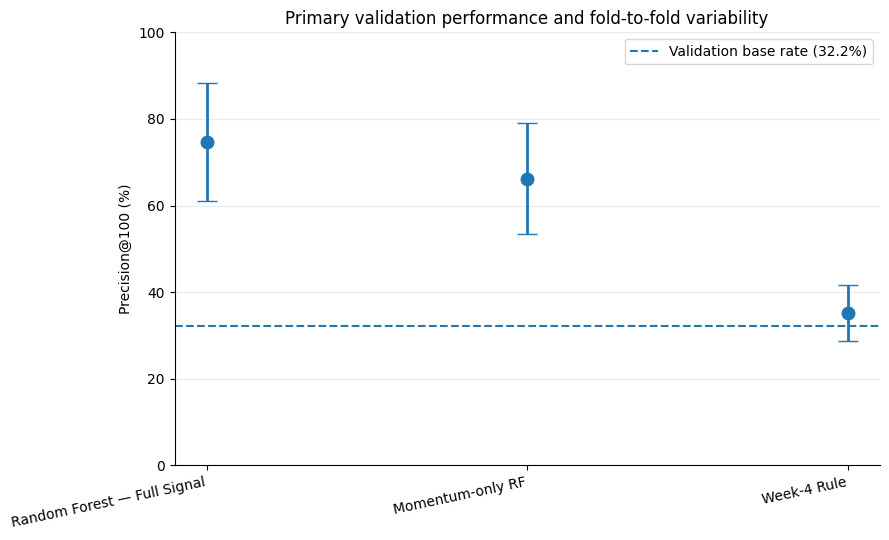

Saved: work/figures/01_validation_performance.png


In [ ]:
validation_results = pd.DataFrame({
    "model": [
        "Random Forest — Full Signal",
        "Momentum-only RF",
        "Week-4 Rule",
    ],
    "mean_p100": [
        74.6,
        66.2,
        35.2,
    ],
    "std_p100": [
        13.6,
        12.8,
        6.4,
    ],
})

BASE_RATE_P100 = 32.2

fig, ax = plt.subplots(figsize=(9, 5.5))

x = np.arange(len(validation_results))

ax.errorbar(
    x,
    validation_results["mean_p100"],
    yerr=validation_results["std_p100"],
    fmt="o",
    capsize=7,
    markersize=9,
    linewidth=2,
)

ax.axhline(
    BASE_RATE_P100,
    linestyle="--",
    linewidth=1.5,
    label=f"Validation base rate ({BASE_RATE_P100:.1f}%)",
)

ax.set_xticks(x)

ax.set_xticklabels(
    validation_results["model"],
    rotation=12,
    ha="right",
)

ax.set_ylabel("Precision@100 (%)")

ax.set_title(
    "Primary validation performance and fold-to-fold variability"
)

ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

fig.tight_layout()

VALIDATION_FIG_PATH = (
    FIGURE_DIR
    / "01_validation_performance.png"
)

fig.savefig(
    VALIDATION_FIG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", VALIDATION_FIG_PATH)

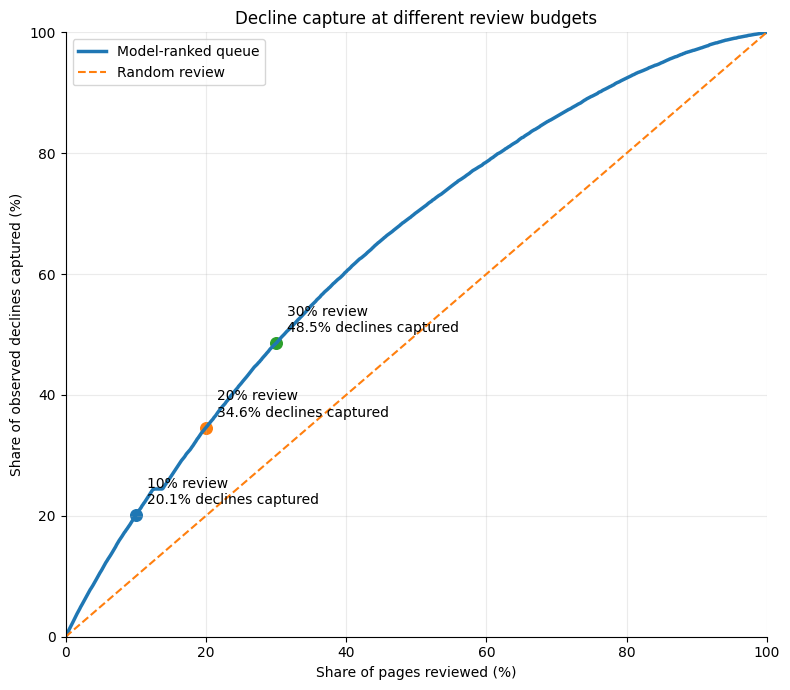

Review top 10% -> capture 20.1% of declines
Review top 20% -> capture 34.6% of declines
Review top 30% -> capture 48.5% of declines
Saved: work/figures/02_cumulative_capture_curve.png


In [ ]:
capture_df = (
    action_queue[
        [
            "queue_rank",
            target_col,
        ]
    ]
    .sort_values("queue_rank")
    .reset_index(drop=True)
)

capture_df["pages_reviewed"] = (
    np.arange(1, len(capture_df) + 1)
)

capture_df["review_share"] = (
    capture_df["pages_reviewed"]
    / len(capture_df)
)

total_declines = capture_df[target_col].sum()

capture_df["declines_captured"] = (
    capture_df[target_col].cumsum()
)

capture_df["capture_share"] = (
    capture_df["declines_captured"]
    / total_declines
)


plot_idx = np.linspace(
    0,
    len(capture_df) - 1,
    800,
).astype(int)

plot_capture = capture_df.iloc[plot_idx]


fig, ax = plt.subplots(figsize=(8, 7))

ax.plot(
    plot_capture["review_share"] * 100,
    plot_capture["capture_share"] * 100,
    linewidth=2.5,
    label="Model-ranked queue",
)

ax.plot(
    [0, 100],
    [0, 100],
    linestyle="--",
    linewidth=1.5,
    label="Random review",
)

capture_results = {}

for review_pct in [10, 20, 30]:

    n = max(
        1,
        int(
            len(capture_df)
            * review_pct
            / 100
        )
    )

    captured_pct = (
        capture_df.iloc[n - 1]["capture_share"]
        * 100
    )

    capture_results[review_pct] = captured_pct

    ax.scatter(
        review_pct,
        captured_pct,
        s=70,
    )

    ax.annotate(
        f"{review_pct}% review\n"
        f"{captured_pct:.1f}% declines captured",
        (review_pct, captured_pct),
        xytext=(8, 8),
        textcoords="offset points",
    )

ax.set_xlabel("Share of pages reviewed (%)")
ax.set_ylabel("Share of observed declines captured (%)")

ax.set_title(
    "Decline capture at different review budgets"
)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.grid(alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

fig.tight_layout()

CAPTURE_FIG_PATH = (
    FIGURE_DIR
    / "02_cumulative_capture_curve.png"
)

fig.savefig(
    CAPTURE_FIG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

for review_pct, captured_pct in capture_results.items():
    print(
        f"Review top {review_pct}% -> "
        f"capture {captured_pct:.1f}% of declines"
    )

print("Saved:", CAPTURE_FIG_PATH)

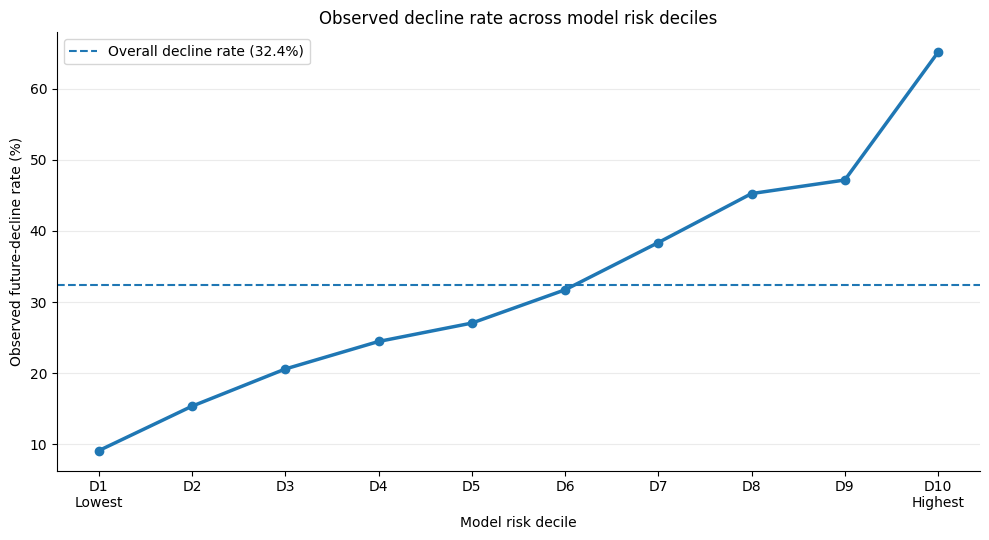

,risk_decile,pages,observed_decline_pct
0,D1\nLowest,6178,9.129168
1,D2,6179,15.374656
2,D3,6179,20.602039
3,D4,6180,24.466019
4,D5,6181,27.050639
5,D6,6178,31.725478
6,D7,6180,38.365696
7,D8,6179,45.250040
8,D9,6256,47.154731
9,D10\nHighest,6105,65.110565


Saved: work/figures/03_risk_decile_outcomes.png


In [ ]:
decile_df = action_queue[
    [
        "risk_percentile",
        target_col,
    ]
].copy()

decile_df["risk_decile"] = pd.cut(
    decile_df["risk_percentile"],
    bins=np.linspace(0, 1, 11),
    labels=[
        "D1\nLowest",
        "D2",
        "D3",
        "D4",
        "D5",
        "D6",
        "D7",
        "D8",
        "D9",
        "D10\nHighest",
    ],
    include_lowest=True,
)

decile_summary = (
    decile_df
    .groupby(
        "risk_decile",
        observed=True,
    )
    .agg(
        pages=(target_col, "size"),
        observed_decline_rate=(target_col, "mean"),
    )
    .reset_index()
)

decile_summary["observed_decline_pct"] = (
    decile_summary["observed_decline_rate"]
    * 100
)

overall_decline_pct = (
    action_queue[target_col].mean()
    * 100
)


fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    decile_summary["risk_decile"].astype(str),
    decile_summary["observed_decline_pct"],
    marker="o",
    linewidth=2.5,
)

ax.axhline(
    overall_decline_pct,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Overall decline rate "
        f"({overall_decline_pct:.1f}%)"
    ),
)

ax.set_xlabel("Model risk decile")
ax.set_ylabel("Observed future-decline rate (%)")

ax.set_title(
    "Observed decline rate across model risk deciles"
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

fig.tight_layout()

DECILE_FIG_PATH = (
    FIGURE_DIR
    / "03_risk_decile_outcomes.png"
)

fig.savefig(
    DECILE_FIG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

display(
    decile_summary[
        [
            "risk_decile",
            "pages",
            "observed_decline_pct",
        ]
    ]
)

print("Saved:", DECILE_FIG_PATH)

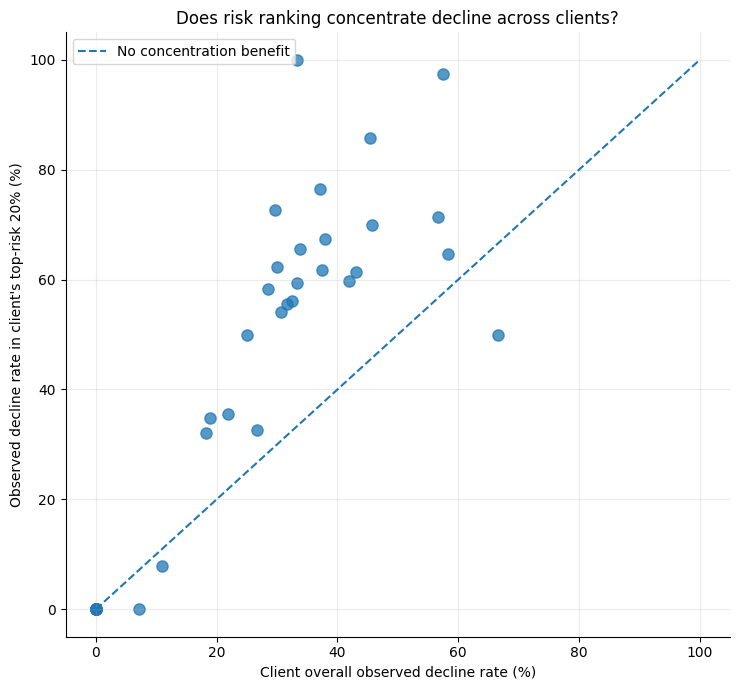

Clients evaluated: 34
Clients with positive concentration: 24 / 34
Median client uplift: 18.1 pp
Saved: work/figures/04_client_generalization.png


In [ ]:
client_rows = []

for client_id, client_df in action_queue.groupby(
    "client_id"
):

    client_df = (
        client_df
        .sort_values(
            "model_risk_score",
            ascending=False,
        )
        .copy()
    )

    overall_rate = (
        client_df[target_col].mean()
    )

    top_n = max(
        1,
        int(
            np.ceil(
                len(client_df)
                * 0.20
            )
        ),
    )

    client_high_risk = (
        client_df.head(top_n)
    )

    high_risk_rate = (
        client_high_risk[target_col].mean()
    )

    client_rows.append({
        "client_id": client_id,
        "pages": len(client_df),
        "top_risk_pages": len(client_high_risk),
        "base_decline_rate": overall_rate,
        "high_risk_decline_rate": high_risk_rate,
        "uplift_pp": (
            high_risk_rate
            - overall_rate
        ) * 100,
    })


client_generalization = pd.DataFrame(
    client_rows
)


fig, ax = plt.subplots(figsize=(7.5, 7))

ax.scatter(
    client_generalization[
        "base_decline_rate"
    ] * 100,
    client_generalization[
        "high_risk_decline_rate"
    ] * 100,
    s=65,
    alpha=0.75,
)

limit = max(
    client_generalization[
        [
            "base_decline_rate",
            "high_risk_decline_rate",
        ]
    ].max()
) * 100

ax.plot(
    [0, limit],
    [0, limit],
    linestyle="--",
    linewidth=1.5,
    label="No concentration benefit",
)

ax.set_xlabel(
    "Client overall observed decline rate (%)"
)

ax.set_ylabel(
    "Observed decline rate in client's top-risk 20% (%)"
)

ax.set_title(
    "Does risk ranking concentrate decline across clients?"
)

ax.grid(alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend()

fig.tight_layout()

CLIENT_FIG_PATH = (
    FIGURE_DIR
    / "04_client_generalization.png"
)

fig.savefig(
    CLIENT_FIG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


clients_with_positive_uplift = int(
    (
        client_generalization["uplift_pp"]
        > 0
    ).sum()
)

median_client_uplift = float(
    client_generalization[
        "uplift_pp"
    ].median()
)

print(
    "Clients evaluated:",
    len(client_generalization),
)

print(
    "Clients with positive concentration:",
    clients_with_positive_uplift,
    "/",
    len(client_generalization),
)

print(
    "Median client uplift:",
    f"{median_client_uplift:.1f} pp",
)

print("Saved:", CLIENT_FIG_PATH)

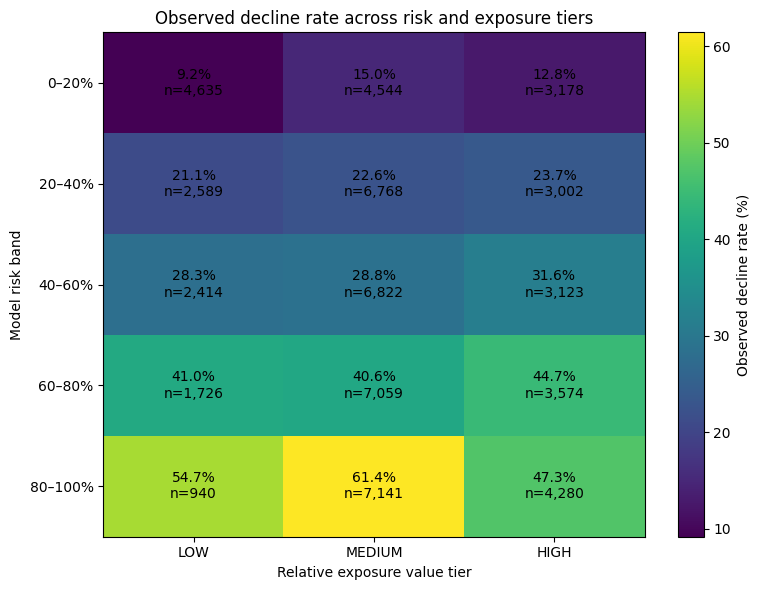

,risk_band,value_tier,observed_decline_rate,pages
0,0–20%,HIGH,0.127753,3178
1,0–20%,LOW,0.091909,4635
2,0–20%,MEDIUM,0.150088,4544
3,20–40%,HIGH,0.237175,3002
4,20–40%,LOW,0.210892,2589
5,20–40%,MEDIUM,0.225621,6768
6,40–60%,HIGH,0.316042,3123
7,40–60%,LOW,0.282933,2414
8,40–60%,MEDIUM,0.287599,6822
9,60–80%,HIGH,0.446558,3574


Saved: work/figures/05_risk_value_matrix.png


In [ ]:
risk_value_df = action_queue[
    [
        "risk_percentile",
        "value_tier",
        target_col,
    ]
].copy()


risk_value_df["risk_band"] = pd.cut(
    risk_value_df["risk_percentile"],
    bins=[
        0.0,
        0.2,
        0.4,
        0.6,
        0.8,
        1.0,
    ],
    labels=[
        "0–20%",
        "20–40%",
        "40–60%",
        "60–80%",
        "80–100%",
    ],
    include_lowest=True,
)


risk_value_summary = (
    risk_value_df
    .groupby(
        [
            "risk_band",
            "value_tier",
        ],
        observed=True,
    )
    .agg(
        observed_decline_rate=(
            target_col,
            "mean",
        ),
        pages=(
            target_col,
            "size",
        ),
    )
    .reset_index()
)


risk_matrix = (
    risk_value_summary
    .pivot(
        index="risk_band",
        columns="value_tier",
        values="observed_decline_rate",
    )
    * 100
)


count_matrix = (
    risk_value_summary
    .pivot(
        index="risk_band",
        columns="value_tier",
        values="pages",
    )
)


column_order = [
    c
    for c in [
        "LOW",
        "MEDIUM",
        "HIGH",
    ]
    if c in risk_matrix.columns
]

risk_matrix = risk_matrix[
    column_order
]

count_matrix = count_matrix[
    column_order
]


fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    risk_matrix.values,
    aspect="auto",
)

ax.set_xticks(
    range(
        len(risk_matrix.columns)
    )
)

ax.set_xticklabels(
    risk_matrix.columns
)

ax.set_yticks(
    range(
        len(risk_matrix.index)
    )
)

ax.set_yticklabels(
    risk_matrix.index.astype(str)
)

ax.set_xlabel(
    "Relative exposure value tier"
)

ax.set_ylabel(
    "Model risk band"
)

ax.set_title(
    "Observed decline rate across risk and exposure tiers"
)


for i in range(
    risk_matrix.shape[0]
):

    for j in range(
        risk_matrix.shape[1]
    ):

        rate = risk_matrix.iloc[i, j]
        n = count_matrix.iloc[i, j]

        if pd.notna(rate):

            ax.text(
                j,
                i,
                f"{rate:.1f}%\n"
                f"n={int(n):,}",
                ha="center",
                va="center",
            )


cbar = fig.colorbar(
    im,
    ax=ax,
)

cbar.set_label(
    "Observed decline rate (%)"
)

fig.tight_layout()

RISK_VALUE_FIG_PATH = (
    FIGURE_DIR
    / "05_risk_value_matrix.png"
)

fig.savefig(
    RISK_VALUE_FIG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

display(risk_value_summary)

print("Saved:", RISK_VALUE_FIG_PATH)

In [ ]:
def capture_at(review_fraction):

    n = max(
        1,
        int(
            len(capture_df)
            * review_fraction
        ),
    )

    return float(
        capture_df.iloc[
            n - 1
        ]["capture_share"]
    )


lowest_decile_rate = float(
    decile_summary.iloc[0][
        "observed_decline_rate"
    ]
)

highest_decile_rate = float(
    decile_summary.iloc[-1][
        "observed_decline_rate"
    ]
)


paper_metrics = {

    "queue": {
        "rows": int(
            len(action_queue)
        ),
        "clients": int(
            action_queue[
                "client_id"
            ].nunique()
        ),
        "overall_decline_rate": float(
            action_queue[
                target_col
            ].mean()
        ),
    },

    "validated_model": {
        "name":
            "Random Forest — Full Signal",

        "precision_at_100_mean":
            0.746,

        "precision_at_100_std":
            0.136,

        "momentum_only_precision_at_100":
            0.662,

        "week4_rule_precision_at_100":
            0.352,
    },

    "review_capture": {
        "top_10pct":
            capture_at(0.10),

        "top_20pct":
            capture_at(0.20),

        "top_30pct":
            capture_at(0.30),
    },

    "risk_deciles": {
        "lowest_decile_decline_rate":
            lowest_decile_rate,

        "highest_decile_decline_rate":
            highest_decile_rate,
    },

    "client_generalization": {
        "clients_evaluated":
            int(
                len(
                    client_generalization
                )
            ),

        "clients_with_positive_uplift":
            clients_with_positive_uplift,

        "median_uplift_pp":
            median_client_uplift,
    },
}


METRICS_PATH = (
    OUTPUT_DIR
    / "w07_paper_metrics.json"
)


with open(
    METRICS_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        paper_metrics,
        f,
        indent=2,
    )


print(
    "Metrics saved:",
    METRICS_PATH,
)

print()

print(
    json.dumps(
        paper_metrics,
        indent=2,
    )
)

Metrics saved: work/outputs/w07_paper_metrics.json

{
  "queue": {
    "rows": 61795,
    "clients": 34,
    "overall_decline_rate": 0.3240229792054373
  },
  "validated_model": {
    "name": "Random Forest \u2014 Full Signal",
    "precision_at_100_mean": 0.746,
    "precision_at_100_std": 0.136,
    "momentum_only_precision_at_100": 0.662,
    "week4_rule_precision_at_100": 0.352
  },
  "review_capture": {
    "top_10pct": 0.20061928781900815,
    "top_20pct": 0.3458023273235779,
    "top_30pct": 0.48539179943065475
  },
  "risk_deciles": {
    "lowest_decile_decline_rate": 0.09129168015539009,
    "highest_decile_decline_rate": 0.6511056511056511
  },
  "client_generalization": {
    "clients_evaluated": 34,
    "clients_with_positive_uplift": 24,
    "median_uplift_pp": 18.059003845427235
  }
}


In [ ]:
expected_figures = [
    VALIDATION_FIG_PATH,
    CAPTURE_FIG_PATH,
    DECILE_FIG_PATH,
    CLIENT_FIG_PATH,
    RISK_VALUE_FIG_PATH,
]

export_receipt = pd.DataFrame([
    {
        "artifact": "Ranked action queue",
        "path": str(QUEUE_PATH),
        "exists": QUEUE_PATH.exists(),
    },
    {
        "artifact": "Paper metrics",
        "path": str(METRICS_PATH),
        "exists": METRICS_PATH.exists(),
    },
    *[
        {
            "artifact": f"Figure {i}",
            "path": str(path),
            "exists": path.exists(),
        }
        for i, path
        in enumerate(
            expected_figures,
            start=1,
        )
    ],
])

display(export_receipt)

assert export_receipt[
    "exists"
].all()

assert (
    target_col
    not in export_queue.columns
)

assert len(export_queue) == len(
    action_queue
)

print(
    "All Section 5 exports generated successfully."
)

,artifact,path,exists
0,Ranked action queue,work/outputs/w07_action_queue.csv,True
1,Paper metrics,work/outputs/w07_paper_metrics.json,True
2,Figure 1,work/figures/01_validation_performance.png,True
3,Figure 2,work/figures/02_cumulative_capture_curve.png,True
4,Figure 3,work/figures/03_risk_decile_outcomes.png,True
5,Figure 4,work/figures/04_client_generalization.png,True
6,Figure 5,work/figures/05_risk_value_matrix.png,True


All Section 5 exports generated successfully.


In [ ]:
PACKAGE_DIR = Path(
    "/content/FlyRank_W07_Paper_Exports"
)

PACKAGE_FIGURE_DIR = (
    PACKAGE_DIR
    / "figures"
)


if PACKAGE_DIR.exists():
    shutil.rmtree(
        PACKAGE_DIR
    )


PACKAGE_DIR.mkdir(
    parents=True
)

PACKAGE_FIGURE_DIR.mkdir(
    parents=True
)


# Copy queue
shutil.copy2(
    QUEUE_PATH,
    PACKAGE_DIR
    / QUEUE_PATH.name,
)


# Copy metrics
shutil.copy2(
    METRICS_PATH,
    PACKAGE_DIR
    / METRICS_PATH.name,
)


# Copy paper figures
for figure_path in expected_figures:

    shutil.copy2(
        figure_path,
        PACKAGE_FIGURE_DIR
        / figure_path.name,
    )


print("Package contents:")

for path in sorted(
    PACKAGE_DIR.rglob("*")
):

    if path.is_file():

        print(
            "-",
            path.relative_to(
                PACKAGE_DIR
            ),
        )

Package contents:
- figures/01_validation_performance.png
- figures/02_cumulative_capture_curve.png
- figures/03_risk_decile_outcomes.png
- figures/04_client_generalization.png
- figures/05_risk_value_matrix.png
- w07_action_queue.csv
- w07_paper_metrics.json


In [ ]:
archive_path = shutil.make_archive(
    "/content/FlyRank_W07_Paper_Exports",
    "zip",
    root_dir="/content",
    base_dir="FlyRank_W07_Paper_Exports",
)

print(
    "ZIP ready:",
    archive_path,
)

from google.colab import files

files.download(
    archive_path
)

ZIP ready: /content/FlyRank_W07_Paper_Exports.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Self-check

Before you submit, confirm each line honestly:

- [x ] Every section above is filled — markdown thinking AND the code that backs it
- [ x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x ] No client names, URLs, or private queries anywhere
- [x ] My claims use careful words: observed, measured, directional, decision-support
- [ x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.